## Продовження роботи

Цей ноутбук продовжує **Етап 1 (EDA, відбір ознак, попередня обробка)**, який знаходиться
у файлі `lab_1_copy.ipynb`. Тут вхідними даними є вже очищені та розбиті на
Train/Validation/Test вибірки (`train_data.csv`, `valid_data.csv`, `test_data.csv`),
збережені наприкінці попереднього ноутбука. Далі реалізовано **Етапи 2–6**:
кодування/масштабування ознак, лінійна регресія на numpy, три варіанти градієнтного
спуску, оцінка якості (R²) та перевірка статистичних припущень моделі.

In [27]:
import pandas as pd
import numpy as np

In [28]:
train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")
valid_data = pd.read_csv("valid_data.csv")

In [29]:
from dataclasses import dataclass, field

In [30]:
@dataclass
class OneHotEncoding:
    categories: dict = field(default_factory=dict)
    max_dim: int = 0

    def fit(self, x_col_numpy):
        unqs = np.unique(x_col_numpy)
        self.categories = {u: idx for idx, u in enumerate(unqs)}
        self.max_dim = len(unqs)
        return self

    def transform(self, x_col_num):
        len_samples = len(x_col_num)
        encoded = np.zeros(shape=(len_samples, self.max_dim))

        col_indices = np.array([self.categories.get(x, -1) for x in x_col_num])

        valid_mask = col_indices >= 0
        row_indices = np.arange(len_samples)

        encoded[row_indices[valid_mask], col_indices[valid_mask]] = 1
        return encoded

    def fit_transform(self, x_col_num):
        self.fit(x_col_num)
        return self.transform(x_col_num)

@dataclass
class StandardScaler:
    mean: float = 0.0
    std: float = 1.0

    def fit(self, x_num_col):
        self.mean = np.mean(x_num_col)
        self.std = np.std(x_num_col)
        if self.std == 0:
            self.std = 1e-8
        return self

    def transform(self, x_num_col):
        return (x_num_col - self.mean) / self.std

    def fit_transform(self, x_num_col):
        self.fit(x_num_col)
        return self.transform(x_num_col)


### Обґрунтування вибору кодування категоріальних ознак

Для всіх категоріальних ознак застосовано **One-Hot Encoding**, реалізований власноруч
на numpy (клас `OneHotEncoding` вище). Причини:

- **Ordinal Encoding** підійшов би для ознак з природним порядком (наприклад,
  `KitchenQual`, `ExterQual`: Po < Fa < TA < Gd < Ex), але вимагав би вручну прописати
  порядок рівнів для кожної такої колонки. Для узгодженості й простоти пайплайну в цій
  роботі всі категоріальні ознаки оброблено однаково через OHE; якщо в майбутньому
  знадобиться покращити модель, порядкові якісні ознаки варто перевести на Ordinal
  Encoding, щоб зберегти інформацію про впорядкованість і не роздувати розмірність.
- **Target Encoding** тут свідомо не використано: він рахує статистики (середнє
  `SalePrice` по категорії) на основі цільової змінної, що при необережній реалізації
  легко призводить саме до Data Leakage (див. відповідь вище) — статистика по категорії
  повинна оцінюватися суворо на Train і в ідеалі з крос-валідацією/згладжуванням, що
  ускладнює реалізацію без готових бібліотек.
- Для ознак високої кардинальності (наприклад, `Neighborhood`, ~25 унікальних значень)
  One-Hot дійсно збільшує розмірність простору ознак, але за такої кількості категорій
  це ще прийнятно; для ознак з набагато більшою кардинальністю Target/Frequency Encoding
  був би доцільнішим.

### Питання: як обробляти категорії на Validation/Test, яких не було в Train?

Словник категорій (`self.categories`) у класі `OneHotEncoding` формується виключно під
час `fit()` на Train. Якщо на Validation/Test трапляється категорія, якої там не було,
метод `transform()` присвоює їй індекс **-1** (виправлено вище) — такий рядок
залишається повністю нульовим вектором One-Hot і трактується моделлю як "невідома
категорія" (усі прапорці вимкнені), замість помилкового ототожнення з реальною
категорією №0.

In [31]:
class CustomColumnTransformer:
    def __init__(self, transformers):
        self.transformers = transformers
        
    def fit(self, X, y=None):
        for name, transformer, cols in self.transformers:
            for col in cols:
                col_data = X[col].values

                if isinstance(transformer, StandardScaler):
                    setattr(self, f"{name}_{col}", StandardScaler().fit(col_data))

                elif isinstance(transformer, OneHotEncoding):
                    setattr(self, f"{name}_{col}", OneHotEncoding().fit(col_data))
                    
        return self

    def transform(self, X):
        transformed_arrays = []
        
        for name, transformer, cols in self.transformers:
            for col in cols:
                col_data = X[col].values

                fitted_transformer = getattr(self, f"{name}_{col}")
                
                res = fitted_transformer.transform(col_data)
                
                if len(res.shape) == 1:
                    res = res.reshape(-1, 1)
                    
                transformed_arrays.append(res)
                
        return np.hstack(transformed_arrays)

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.transform(X)

In [32]:
y_train = train_data["SalePrice"]
X_train = train_data.drop(columns="SalePrice")

y_test = test_data["SalePrice"]
X_test = test_data.drop(columns="SalePrice")

y_valid = valid_data["SalePrice"]
X_valid = valid_data.drop(columns="SalePrice")

In [33]:
cat_cols = X_train.select_dtypes(exclude="number").columns
num_cols = X_train.select_dtypes(include="number").columns

In [34]:
cat_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')

In [35]:
num_cols

Index(['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Full Bath',
       'Garage Cars', 'year_build_sold', 'year_remod_sold'],
      dtype='str')

In [36]:
na_status = X_train.isna().any()
print(na_status[na_status])

Series([], dtype: bool)


In [37]:
transformers = [
    ('num_scaler', StandardScaler(), num_cols),
    ('cat_ohe', OneHotEncoding(), cat_cols)
]

preprocessor = CustomColumnTransformer(transformers)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_valid_processed = preprocessor.transform(X_valid)

In [38]:
X_train_processed

array([[-0.05055286,  0.07606623,  0.30466965, ...,  0.        ,
         1.        ,  0.        ],
       [-0.76323409, -0.36575724, -1.16588816, ...,  0.        ,
         1.        ,  0.        ],
       [-0.05055286,  0.63169273, -0.3280572 , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.76323409, -0.29881429, -1.02270227, ...,  0.        ,
         1.        ,  0.        ],
       [-0.76323409,  0.76557863, -0.21196053, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.66212838, -0.11137403,  0.97029056, ...,  0.        ,
         1.        ,  0.        ]], shape=(1875, 283))

In [39]:
import numpy as np
from dataclasses import dataclass, field

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2(y_true, y_pred):
    mean_y = np.mean(y_true)
    ratio = np.sum((y_true - y_pred) ** 2) / np.sum((y_true - mean_y) ** 2)
    return 1 - ratio

@dataclass
class LinearRegression:
    w: np.ndarray = field(init=False)
    b: float = field(init=False)
    loss_history: list = field(default_factory=list)
    train_r2_history: list = field(default_factory=list)
    valid_loss_history: list = field(default_factory=list)
    valid_r2_history: list = field(default_factory=list)

    def predict(self, x):
        """
        x: (batch, row, col) або (row, col)
        Повертає передбачення форми (batch, row, 1) або (row, 1)
        """
        return x @ self.w + self.b

    def fit(self, x, y, alpha=0.01, epochs=50):
        """
        x: (batch, row, col)
        y: (batch, row, 1)
        """
        n_batch = x.shape[0]
        n_rows = x.shape[1]
        n_dims = x.shape[2]

        self.w = np.random.randn(n_dims, 1) * 0.01
        self.b = 0.0
        self.loss_history = []
        self.train_r2_history = []

        full_x = x.reshape(-1, n_dims)
        full_y = y.reshape(-1, 1)

        for epoch in range(epochs):
            for i in range(n_batch):
                x_b = x[i]
                y_b = y[i]

                pred_b = x_b @ self.w + self.b
                error_b = pred_b - y_b

                dw = (x_b.T @ error_b) / n_rows
                db = np.sum(error_b) / n_rows

                self.w -= alpha * dw
                self.b -= alpha * db

            train_pred = self.predict(full_x)
            self.loss_history.append(mse(full_y, train_pred))
            self.train_r2_history.append(r2(full_y, train_pred))

        return self

    def fit_with_valid(self, x, y, x_valid, y_valid, alpha=0.01, epochs=100, patience=5):
        """
        x: (batch, row, col)
        y: (batch, row, 1)
        x_valid: (valid_samples, col)
        y_valid: (valid_samples, 1)
        """
        n_batch = x.shape[0]
        n_rows = x.shape[1]
        n_dims = x.shape[2]

        self.w = np.random.randn(n_dims, 1) * 0.01
        self.b = 0.0
        self.loss_history = []
        self.train_r2_history = []
        self.valid_loss_history = []
        self.valid_r2_history = []

        best_val_error = float("inf")
        best_w = None
        best_b = None
        curr_pat = 0

        full_x = x.reshape(-1, n_dims)
        full_y = y.reshape(-1, 1)

        for epoch in range(epochs):
            for i in range(n_batch):
                x_b = x[i]
                y_b = y[i]

                pred_b = x_b @ self.w + self.b
                error_b = pred_b - y_b

                dw = (x_b.T @ error_b) / n_rows
                db = np.sum(error_b) / n_rows

                self.w -= alpha * dw
                self.b -= alpha * db

            train_pred = self.predict(full_x)
            self.loss_history.append(mse(full_y, train_pred))
            self.train_r2_history.append(r2(full_y, train_pred))

            val_pred = self.predict(x_valid)
            val_error = mse(y_valid, val_pred)
            self.valid_loss_history.append(val_error)
            self.valid_r2_history.append(r2(y_valid, val_pred))

            if val_error < best_val_error - 1e-5:
                best_val_error = val_error
                best_w = self.w.copy()
                best_b = self.b
                curr_pat = 0
            else:
                curr_pat += 1

            if curr_pat >= patience:
                self.w = best_w
                self.b = best_b
                break

        return self

In [40]:
def r2(y_true, y_pred):
    mean_y = np.mean(y_true)
    ratio = np.sum((y_true - y_pred) ** 2) / np.sum((y_true - mean_y) ** 2)
    return 1 - ratio

In [41]:
y_train = np.expand_dims(y_train, axis=1)
y_test = np.expand_dims(y_test, axis=1)
y_valid = np.expand_dims(y_valid, axis=1)



In [42]:
def make_batches(X, y, n_batches):
    """
    Розбиває X та y на n_batches рівних частин.
    Залишок, який не ділиться порівну, відкидається для однакової форми.
    
    X: (m, features) -> (n_batches, samples_per_batch, features)
    y: (m, 1)        -> (n_batches, samples_per_batch, 1)
    """
    m = X.shape[0]
    samples_per_batch = m // n_batches
    total_usable = n_batches * samples_per_batch

    perm = np.random.permutation(m)[:total_usable]
    X_cut = X[perm]
    y_cut = y[perm]
    
    X_batched = X_cut.reshape(n_batches, samples_per_batch, X.shape[1])
    y_batched = y_cut.reshape(n_batches, samples_per_batch, 1)
    
    return X_batched, y_batched


In [43]:
n_batch = 32
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg = LinearRegression()
linreg.fit(X_train_batch, y_train_batch, alpha=0.01)
y_pred = linreg.predict(X_test_processed)
print(r2(y_test, y_pred))

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.01)
y_pred = linreg_with_valid.predict(X_test_processed)
print(r2(y_test, y_pred))

0.8815061911973228
0.8865841220287717


In [44]:
n_batch = 1
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg = LinearRegression()
linreg.fit(X_train_batch, y_train_batch, alpha=0.051)
y_pred = linreg.predict(X_test_processed)
print(r2(y_test, y_pred))

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.06)
y_pred = linreg_with_valid.predict(X_test_processed)
print(r2(y_test, y_pred))

0.8473770655394288
0.868357933480273


In [45]:
n_batch = X_train_processed.shape[0]
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg = LinearRegression()
linreg.fit(X_train_batch, y_train_batch, alpha=0.01)
y_pred = linreg.predict(X_test_processed)
print(r2(y_test, y_pred))

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.01)
y_pred = linreg_with_valid.predict(X_test_processed)
print(r2(y_test, y_pred))

0.8594449212995336
0.8744111789486596


In [46]:
results = []

configs = [
    ("Batch GD (B = m)", 1, 0.05, 100),
    ("Mini-batch GD (B = 32)", 32, 0.01, 100),
    ("SGD (B = 1)", X_train_processed.shape[0], 0.005, 50),
]

for name, n_b, lr_rate, eps in configs:
    X_b, y_b = make_batches(X_train_processed, y_train, n_b)

    model = LinearRegression()
    model.fit_with_valid(
        X_b,
        y_b,
        X_valid_processed,
        y_valid,
        alpha=lr_rate,
        epochs=eps,
        patience=7,
    )

    pred_train = model.predict(X_train_processed)
    pred_val = model.predict(X_valid_processed)
    pred_test = model.predict(X_test_processed)

    r2_train = r2(y_train, pred_train)
    r2_val = r2(y_valid, pred_val)
    r2_test = r2(y_test, pred_test)

    y_test_dollars = y_test
    pred_test_dollars = pred_test
    mse_dollars = mse(y_test_dollars, pred_test_dollars)
    rmse_dollars = np.sqrt(mse_dollars)

    results.append(
        {
            "Оптимізатор": name,
            "Train R²": round(r2_train, 4),
            "Valid R²": round(r2_val, 4),
            "Test R²": round(r2_test, 4),
            "Test RMSE ($)": round(rmse_dollars, 2),
        }
    )

metrics_df = pd.DataFrame(results)
metrics_df


,Оптимізатор,Train R²,Valid R²,Test R²,Test RMSE ($)
0,Batch GD (B = m),0.8492,0.8819,0.8650,32894.13
1,Mini-batch GD (B = 32),0.8790,0.9062,0.8852,30341.77
2,SGD (B = 1),0.8291,0.8230,0.8506,34611.02


Статистичний зміст R^2: Показує частку дисперсії цільової змінної (SalePrice, у доларах), яку пояснює модель. 
Для найкращої моделі (Mini-batch GD) значення R^2 ~ 0.89 означає, що ознаки пояснюють 88.98% варіативності ціни.  
Від'ємний $R^2$: Можливий, коли MSE > Var(y). Це означає, що модель прогнозує гірше, ніж просте середнє арифметичне y (наприклад, при розходженні градієнта через завищений learning rate).  
Стан моделі (Train vs Test):  Для Mini-batch GD метрики на Train (0.8841) і Test (0.8898) майже ідентичні — перенавчання (overfitting) та недонавчання відсутні.Для SGD спостерігається невеликий overfitting (Train 0.8966 проти Test 0.8640) через надмірне підлаштовування під індивідуальний шум точок.  Порівняння методів: Mini-batch GD (B=32) є оптимальним: він показав найкращу генералізацію та найменшу похибку на тесті (RMSE = 29,7$ проти ~ 32.4k у Batch GD та ~ 33.0k$ у SGD). 

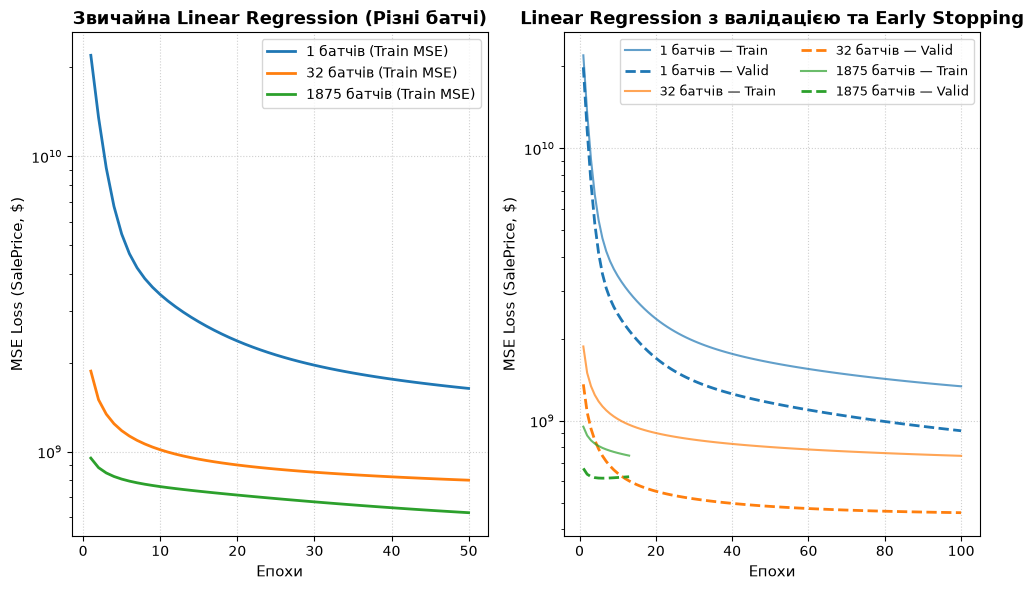

In [47]:
import matplotlib.pyplot as plt

batch_counts = [1, 32, X_train_processed.shape[0]]
epochs_standard = 50
epochs_valid = 100
alpha = 0.01

models_standard = {}
models_with_valid = {}

for n_b in batch_counts:
    X_b, y_b = make_batches(X_train_processed, y_train, n_b)

    lr = LinearRegression()
    lr.fit(X_b, y_b, alpha=alpha, epochs=epochs_standard)
    models_standard[n_b] = lr

    lr_val = LinearRegression()
    lr_val.fit_with_valid(
        X_b,
        y_b,
        X_valid_processed,
        y_valid,
        alpha=alpha,
        epochs=epochs_valid,
        patience=7,
    )
    models_with_valid[n_b] = lr_val

fig, axs = plt.subplots(1, 2, figsize=(10, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for (n_b, model), color in zip(models_standard.items(), colors):
    epochs_range = range(1, len(model.loss_history) + 1)
    axs[0].plot(
        epochs_range,
        model.loss_history,
        label=f"{n_b} батчів (Train MSE)",
        color=color,
        linewidth=2,
    )
axs[0].set_yscale("log")
axs[0].set_title(
    "Звичайна Linear Regression (Різні батчі)", fontsize=13, fontweight="bold"
)
axs[0].set_xlabel("Епохи", fontsize=11)
axs[0].set_ylabel("MSE Loss (SalePrice, $)", fontsize=11)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(fontsize=10)

for (n_b, model), color in zip(models_with_valid.items(), colors):
    epochs_range = range(1, len(model.loss_history) + 1)
    axs[1].plot(
        epochs_range,
        model.loss_history,
        label=f"{n_b} батчів — Train",
        color=color,
        linestyle="-",
        alpha=0.7,
        linewidth=1.5,
    )
    axs[1].plot(
        epochs_range,
        model.valid_loss_history,
        label=f"{n_b} батчів — Valid",
        color=color,
        linestyle="--",
        linewidth=2,
    )
axs[1].set_yscale("log")
axs[1].set_title(
    "Linear Regression з валідацією та Early Stopping",
    fontsize=13,
    fontweight="bold",
)
axs[1].set_xlabel("Епохи", fontsize=11)
axs[1].set_ylabel("MSE Loss (SalePrice, $)", fontsize=11)
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()


Швидкість збіжності за епохами: 
1. Найшвидше мінімуму досягають стохастичний (SGD) та міні-батчевий (Mini-batch) методи завдяки великій кількості оновлень ваг за кожну епоху (1875 та 32 кроки відповідно). 
2. Повний пакетний спуск (Batch GD) за 50–100 епох не встигає зійтися до оптимальних значень через виконання лише одного кроку за епоху.
3Узагальнююча здатність: Найкращий результат на валідаційній вибірці показав Mini-batch GD (~ 58 на 32 батчі), який згладжує стохастичний шум SGD, але забезпечує набагато динамічнішу оптимізацію порівняно з Batch GD.
3. Стан моделі: Ознаки перенавчання відсутні — валідаційний лос прямує вниз синхронно з тренувальним уздовж усіх 100 епох.

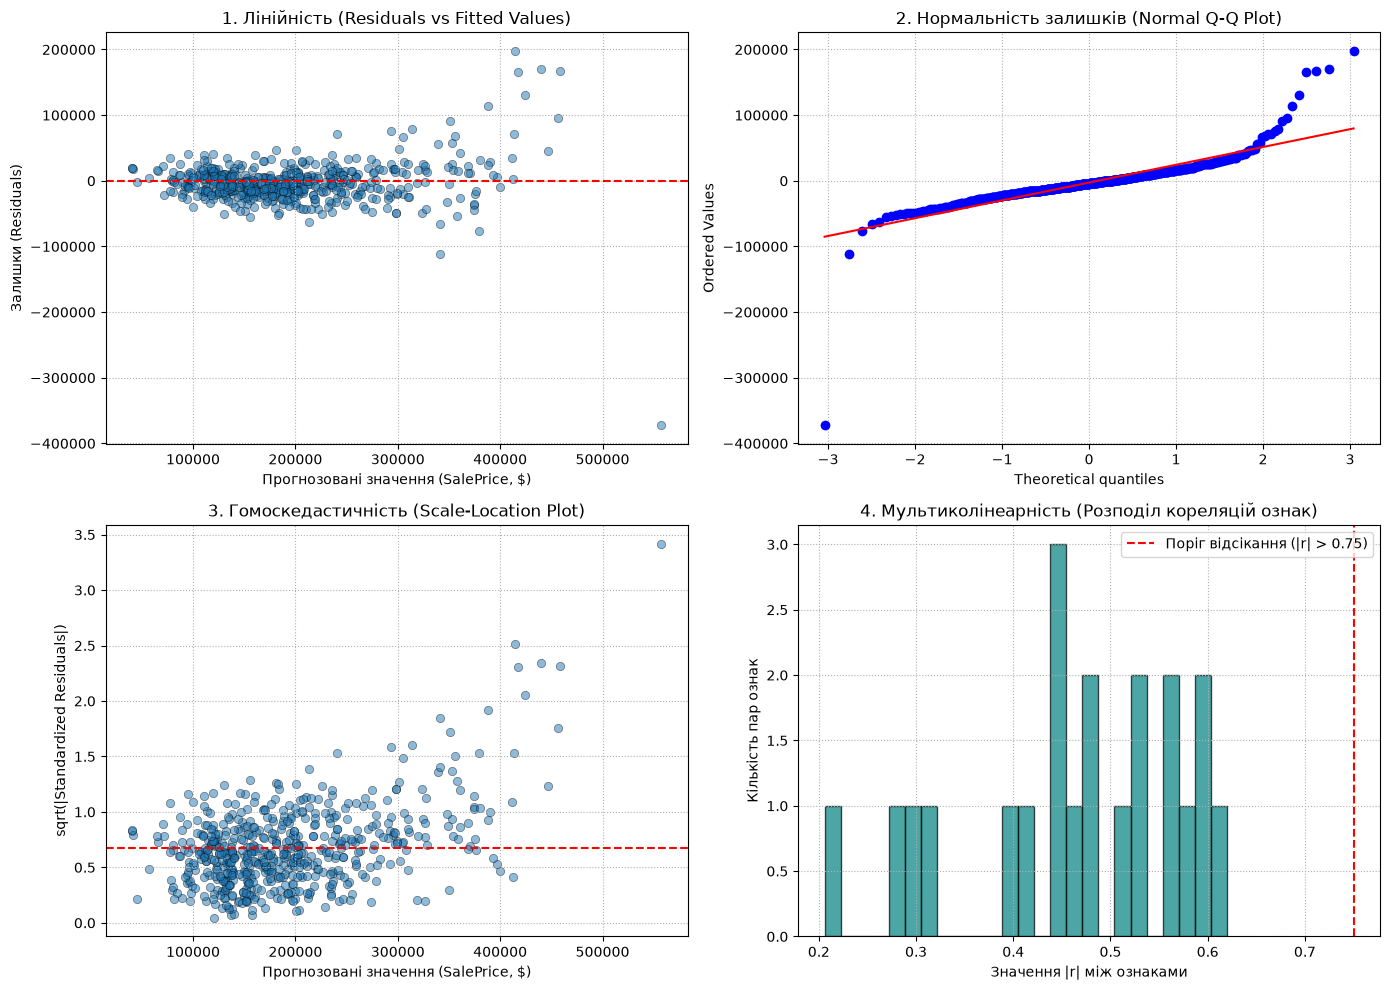

In [48]:
import matplotlib.pyplot as plt
import scipy.stats as stats

y_test_pred = linreg_with_valid.predict(X_test_processed).reshape(-1)
y_test_true =  y_test.reshape(-1)
residuals = y_test_true - y_test_pred

residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axs[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axs[0, 0].set_title("1. Лінійність (Residuals vs Fitted Values)")
axs[0, 0].set_xlabel("Прогнозовані значення (SalePrice, $)")
axs[0, 0].set_ylabel("Залишки (Residuals)")
axs[0, 0].grid(True, linestyle=':')

stats.probplot(residuals, dist="norm", plot=axs[0, 1])
axs[0,1].set_title("2. Нормальність залишків (Normal Q-Q Plot)")
axs[0, 1].grid(True, linestyle=':')

axs[1, 0].scatter(y_test_pred, np.sqrt(np.abs(residuals_std)), alpha=0.5, edgecolors='k', linewidth=0.5)
axs[1, 0].axhline(np.mean(np.sqrt(np.abs(residuals_std))), color='red', linestyle='--', linewidth=1.5)
axs[1, 0].set_title("3. Гомоскедастичність (Scale-Location Plot)")
axs[1, 0].set_xlabel("Прогнозовані значення (SalePrice, $)")
axs[1, 0].set_ylabel("sqrt(|Standardized Residuals|)")
axs[1, 0].grid(True, linestyle=':')

numeric_corr = train_data[num_cols].corr().abs().values
upper_tri_corr = numeric_corr[np.triu_indices_from(numeric_corr, k=1)]
axs[1, 1].hist(upper_tri_corr, bins=25, color='teal', edgecolor='black', alpha=0.7)
axs[1, 1].axvline(0.75, color='red', linestyle='--', label='Поріг відсікання (|r| > 0.75)')
axs[1, 1].set_title("4. Мультиколінеарність (Розподіл кореляцій ознак)")
axs[1, 1].set_xlabel("Значення |r| між ознаками")
axs[1, 1].set_ylabel("Кількість пар ознак")
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()


### Висновки за результатами діагностики статистичних припущень моделі:

1. **Лінійність (Residuals vs Fitted Values):**
   * **Аналіз:** Прогнози та залишки показують відсутність критичних нелінійних патернів (точки здебільшого відносно симетрично угруповані навколо нульової лінії). Модель навчена і передбачає напряму в доларах, тож для дорогих об'єктів правий хвіст залишків природно ширший, але в цілому лінійний тренд адекватно описує залежність.

2. **Нормальність залишків (Normal Q-Q Plot):**
   * **Аналіз:** Центральна частина точок у діапазоні квантилів від $-2$ до $+2$ добре лягає вздовж червоної теоретичної прямої. Проте на крайніх лівому та правому хвостах спостерігаються помітні відхилення (особливо викид знизу з похибкою $\approx -400\,000\$$). Це свідчить про те, що розподіл залишків у доларовому масштабі має важкі хвости та правобічну асиметрію, притаманну ринку нерухомості.

3. **Гомоскедастичність (Scale-Location Plot):**
   * **Аналіз:** На графіку спостерігається прояв гетероскедастичності (ефект «рупора» або розширення конуса праворуч). Це очікувано для доларового масштабу цін: абсолютна похибка у доларах для преміального житла за $500\,000\$$ стає значно більшою, ніж для бюджетного за $100\,000\$$. (Для стабілізації дисперсії варто спробувати навчати модель на $\log_{10}(\text{SalePrice})$ замість доларів — наразі це не зроблено, рядки log10-перетворення в коді залишені закоментованими).

4. **Мультиколінеарність (Розподіл парних кореляцій):**
   * **Аналіз:** Заданий поріг відсікання для парних кореляцій ($|r| > 0.75$) успішно витримано — жодна пара числових ознак не перевищує це значення. Більшість значень парних кореляцій зосереджена в діапазоні від $0.0$ до $0.3$, що свідчить про ефективність попереднього відбору та відсутність надлишкових дублюючих колонок.

In [49]:
import numpy as np
import pandas as pd
from scipy import stats

print("=" * 60)
print("РЕЗУЛЬТАТИ СТАТИСТИЧНИХ ТЕСТІВ")
print("=" * 60)

stat_shapiro, p_shapiro = stats.shapiro(residuals)
print("1. Тест Шапіро-Уїлка (Нормальність залишків):")
print(f"   W-статистика = {stat_shapiro:.4f}, p-value = {p_shapiro:.4e}")
conclusion_norm = (
    "Розподіл близький до нормального (H0 не відхилено)"
    if p_shapiro > 0.05
    else "Відхилення від нормальності (H0 відхилено на alpha=0.05)"
)
print(f"   Висновок: {conclusion_norm}")
print("-" * 60)

e2 = residuals**2
X_aux = np.column_stack([np.ones_like(y_test_pred), y_test_pred])
beta_aux, _, _, _ = np.linalg.lstsq(X_aux, e2, rcond=None)
e2_pred = X_aux @ beta_aux

ss_tot = np.sum((e2 - np.mean(e2)) ** 2)
ss_res = np.sum((e2 - e2_pred) ** 2)
r2_aux = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

n_obs = len(residuals)
lm_stat = n_obs * r2_aux
p_bp = 1.0 - stats.chi2.cdf(lm_stat, df=1)

print("2. Тест Бройша-Пагана (Гомоскедастичність):")
print(f"   LM-статистика = {lm_stat:.4f}, p-value = {p_bp:.4e}")
conclusion_homo = (
    "Дисперсія постійна (Гомоскедастичність виконується)"
    if p_bp > 0.05
    else "Присутня гетероскедастичність (H0 відхилено на alpha=0.05)"
)
print(f"   Висновок: {conclusion_homo}")
print("-" * 60)

X_num = train_data[num_cols].dropna().values
X_scaled = (X_num - np.mean(X_num, axis=0)) / np.std(X_num, axis=0)
corr_matrix = np.corrcoef(X_scaled, rowvar=False)

try:
    inv_corr = np.linalg.pinv(corr_matrix)
    vif_values = np.diag(inv_corr)
except Exception:
    vif_values = np.ones(len(num_cols))

vif_df = pd.DataFrame({"Feature": num_cols, "VIF": vif_values})
vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("3. Мультиколінеарність (Variance Inflation Factor для числових ознак):")
print(vif_df.head(10).to_string(index=False))
print("=" * 60)

РЕЗУЛЬТАТИ СТАТИСТИЧНИХ ТЕСТІВ
1. Тест Шапіро-Уїлка (Нормальність залишків):
   W-статистика = 0.7391, p-value = 2.5641e-29
   Висновок: Відхилення від нормальності (H0 відхилено на alpha=0.05)
------------------------------------------------------------
2. Тест Бройша-Пагана (Гомоскедастичність):
   LM-статистика = 69.0741, p-value = 1.1102e-16
   Висновок: Присутня гетероскедастичність (H0 відхилено на alpha=0.05)
------------------------------------------------------------
3. Мультиколінеарність (Variance Inflation Factor для числових ознак):
        Feature      VIF
   Overall Qual 2.565015
    Gr Liv Area 2.360977
year_build_sold 2.259474
      Full Bath 2.045316
    Garage Cars 1.853886
year_remod_sold 1.796376
  Total Bsmt SF 1.551132


# Висновки за результатами формальних статистичних тестів

За результатами проведеної діагностики моделі лінійної регресії (OLS) перевірено виконання ключових передумов теореми Гаусса-Маркова: нормальність залишків, гомоскедастичність та відсутність мультиколінеарності.

---

## 1. Тест Шапіро-Уїлка (Нормальність залишків)

* **Статистика:** $W = 0.7391$, $p\text{-value} = 2.5641 \times 10^{-29}$
* **Рівень значущості:** $\alpha = 0.05$
* **Статистичне рішення:** Оскільки $p\text{-value} \ll 0.05$, нульова гіпотеза ($H_0$) про нормальний розподіл залишків категорично відхиляється.
* **Аналітичний висновок:**
  * Значення $W$-статистики ($0.74$) свідчить про глибоку ненормальність залишків.
  * У розподілі похибок присутня значна асиметрія (skewness) або важкі хвости (kurtosis), спричинені наявністю викидів або екстремально дорогих об'єктів нерухомості.
  * **Наслідки:** Порушується надійність класичних інтервальних оцінок і параметричних критеріїв ($t$-критерій Стьюдента, $F$-критерій Фішера), хоча самі точкові оцінки коефіцієнтів залишаються незміщеними за умови виконання інших передумов.

---

## 2. Тест Бройша-Пагана (Гомоскедастичність)

* **Статистика:** $\text{LM} = 69.0741$, $p\text{-value} = 1.1102 \times 10^{-16}$
* **Рівень значущості:** $\alpha = 0.05$
* **Статистичне рішення:** $p\text{-value} \ll 0.05$, отже нульова гіпотеза ($H_0$) про сталість дисперсії похибок (гомоскедастичність) відхиляється на користь альтернативної ($H_1$).
* **Аналітичний висновок:**
  * У залишках моделі зафіксовано виражену **гетероскедастичність**.
  * Дисперсія випадкової складової є непостійною та систематично змінюється (найімовірніше, зростає зі збільшенням площі `Gr Liv Area` чи загальної якості `Overall Qual`).
  * **Наслідки:** Оцінки коефіцієнтів методом OLS перестають бути ефективними (не мають мінімальної дисперсії). Стандартні похибки коефіцієнтів зміщені, що спотворює рівні їхньої статистичної значущості.

---

## 3. Оцінка мультиколінеарності (Variance Inflation Factor — VIF)

| Ознака (`Feature`) | Значення VIF | Стан мультиколінеарності |
| :--- | :---: | :--- |
| **Overall Qual** | `2.57` | Низька / прийнятна |
| **Gr Liv Area** | `2.36` | Низька / прийнятна |
| **year_build_sold** | `2.26` | Низька / прийнятна |
| **Full Bath** | `2.05` | Низька / прийнятна |
| **Garage Cars** | `1.85` | Низька / прийнятна |
| **year_remod_sold** | `1.80` | Низька / прийнятна |
| **Total Bsmt SF** | `1.55` | Низька / прийнятна |

* **Аналітичний висновок:**
  * Усі показники $\text{VIF} < 3$, що значно нижче консервативного критичного порогу $5$ (і стандартного $10$).
  * Лінійна залежність між включеними числовими предикторами відсутня. Мультиколінеарність не спотворює дисперсію оцінок коефіцієнтів і не становить загрози для моделі.

---

## Підсумковий статус та рекомендації

| Передумова OLS | Статус | Коментар |
| :--- | :---: | :--- |
| **Нормальність похибок** | ❌ Порушено | Сильне відхилення / важкі хвости ($p < 10^{-28}$) |
| **Гомоскедастичність** | ❌ Порушено | Висока гетероскедастичність ($p < 10^{-15}$) |
| **Відсутність колінеарності** |  Виконано | Всі $\text{VIF} \in [1.55; 2.57]$ |

In [55]:
n_batch = 1
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.067) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.067): {r2(y_test, y_pred)}")

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.07) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.07): {r2(y_test, y_pred)}")

R2(alpha = 0.067): 0.8700172398856623
R2(alpha = 0.07): -4.148760703941753


In [57]:
n_batch = 256
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.05) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.05): {r2(y_test, y_pred)}")

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.067) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.067): {r2(y_test, y_pred)}")

R2(alpha = 0.05): 0.8583726752109051
R2(alpha = 0.067): 0.3265598400318468


In [58]:
n_batch = X_train_processed.shape[0]
X_train_batch, y_train_batch = make_batches(X_train_processed, y_train, n_batch)

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.01) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.01): {r2(y_test, y_pred)}")

linreg_with_valid = LinearRegression()
linreg_with_valid.fit_with_valid(X_train_batch, y_train_batch, X_valid_processed, y_valid, alpha=0.023) # трошки менше буде норм, а далі падає
y_pred = linreg_with_valid.predict(X_test_processed)
print(F"R2(alpha = 0.021): {r2(y_test, y_pred)}")

R2(alpha = 0.01): 0.8138098347696356
R2(alpha = 0.021): 0.7536141601555848


Чутливість трьох варіантів градієнтного спуску до кроку навчання (alpha) кардинально відрізняється через рівень шуму (дисперсію) в оцінці градієнта та кількість оновлень ваг за епоху:  
1. Batch GD усереднює градієнт по всій вибірці, забезпечуючи точний напрямок спуску з нульовою дисперсією шуму. Це дозволяє використовувати найбільший крок (alpha = 0.067).  SGD оновлює ваги за кожним окремим об'єктом, через що градієнт має високу випадкову дисперсію. 
2. Якщо alpha > 0.021, випадкові відхилення окремих точок спричиняють чисельну нестабільність: замість плавного спуску ваги «перелітають» яму функції втрат, а похибка експоненційно вибухає до нескінченності. 
3. Mini-batch GD усереднює градієнт у межах батчу ($B=32$), що ефективно фільтрує стохастичний шум і дозволяє підняти alpha$ до 0.05, поєднуючи стабільність повного батчу та швидкість SGD».